In [31]:

import ehrapy as ep
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import anndata as ad


from tableone import TableOne

import warnings
from fairlearn.datasets import fetch_diabetes_hospital

colors = sns.color_palette("tab10", n_colors=14)

In [9]:

data = fetch_diabetes_hospital(as_frame=True)
df = data.data.copy()
df["readmitted"] = data.target


In [24]:
obs_cols = ["age", "readmitted", "readmit_binary", "race", "gender", "discharge_disposition_id"]
X_cols = [c for c in df.columns if c not in obs_cols]

adata = ad.AnnData(X=df[X_cols].astype(str), obs=df[obs_cols])
adata.var_names = X_cols

In [26]:
adata.obs["Age group"] = np.where(
    adata.obs["age"] == "'30 years or younger'", "Younger than 30", "Older than 30"
)

ep.ad.infer_feature_types(adata)
adata = ep.pp.encode(adata, autodetect=True)

print(adata.var_names.tolist())
print(adata.obs.columns.tolist())

! Feature  was detected as categorical features stored numerically.Please verify and correct using `ep.ad.replace_feature_types` if necessary.


 Detected feature types for AnnData object with 101766 obs and 79 vars
╠══ 📅 Date features
╠══ 📐 Numerical features
║   ╠══ num_lab_procedures
║   ╚══ num_medications
╚══ 🗂️ Categorical features
    ╠══ A1Cresult (4 categories); one-hot encoded
    ╠══ admission_source_id (3 categories); one-hot encoded
    ╠══ change (2 categories); one-hot encoded
    ╠══ diabetesMed (2 categories); one-hot encoded
    ╠══ had_emergency (2 categories); one-hot encoded
    ╠══ had_inpatient_days (2 categories); one-hot encoded
    ╠══ had_outpatient_days (2 categories); one-hot encoded
    ╠══ insulin (4 categories); one-hot encoded
    ╠══ max_glu_serum (4 categories); one-hot encoded
    ╠══ medicaid (2 categories); one-hot encoded
    ╠══ medical_specialty (6 categories); one-hot encoded
    ╠══ medicare (2 categories); one-hot encoded
    ╠══ num_procedures (7 categories); one-hot encoded
    ╠══ number_diagnoses (16 categories); one-hot encoded
    ╠══ primary_diagnosis (5 categories); one-hot encoded
    ╚══ time_in_hospital (14 categories); one-hot encoded

! Detected no columns that need to be encoded. Leaving passed AnnData object unchanged.
['ehrapycat_admission_source_id_Emergency', 'ehrapycat_admission_source_id_Other', 'ehrapycat_admission_source_id_Referral', 'ehrapycat_time_in_hospital_1', 'ehrapycat_time_in_hospital_10', 'ehrapycat_time_in_hospital_11', 'ehrapycat_time_in_hospital_12', 'ehrapycat_time_in_hospital_13', 'ehrapycat_time_in_hospital_14', 'ehrapycat_time_in_hospital_2', 'ehrapycat_time_in_hospital_3', 'ehrapycat_time_in_hospital_4', 'ehrapycat_time_in_hospital_5', 'ehrapycat_time_in_hospital_6', 'ehrapycat_time_in_hospital_7', 'ehrapycat_time_in_hospital_8', 'ehrapycat_time_in_hospital_9', 'ehrapycat_medical_specialty_Cardiology', 'ehrapycat_medical_specialty_Emergency/Trauma', 'ehrapycat_medical_specialty_Family/GeneralPractice', 'ehrapycat_medical_specialty_InternalMedicine', 'ehrapycat_medical_specialty_Missing', 'ehrapycat_medical_specialty_Other', 'ehrapycat_num_procedures_0', 'ehrapycat_num_procedures_1', 'ehrap

In [27]:
# obs_cols = ["age", "readmitted", "readmit_binary", "race", "gender", "discharge_disposition_id"]
# X_cols = [c for c in df.columns if c not in obs_cols]

# adata = ad.AnnData(X=df[X_cols].astype(str), obs=df[obs_cols])
# adata.var_names = X_cols

# adata.obs["Age group"] = np.where(
#     adata.obs["age"] == "'30 years or younger'", "Younger than 30", "Older than 30"
# )

# ep.ad.infer_feature_types(adata)
# adata = ep.pp.encode(adata, autodetect=True)

adata_scaled_together = ep.pp.scale_norm(adata, vars="num_medications", copy=True)
adata_scaled_separate = ep.pp.scale_norm(
    adata, vars="num_medications", group_key="Age group", copy=True
)

In [32]:
def plot_hist_normalization(
    adata,
    adata_scaled_together,
    adata_scaled_separate,
    group_key="age_group",
    var_of_interest="num_medications",
    pretty_name="num_medications",
):
    """Plot histogram of original data, jointly normalized, and split normalization (by group_key variable)."""

    fig, axs = plt.subplots(1, 3, figsize=(21, 5))

    # plot raw adata
    cols = [colors[10], colors[11]]

    for i, group in enumerate(adata.obs[group_key].unique()):
        adata_group = adata[adata.obs[group_key] == group, var_of_interest]
        axs[0].hist(
            adata_group.X,
            bins=10,
            alpha=0.7,
            label=group,
            orientation="horizontal",
            weights=np.ones(len(adata_group)) / len(adata_group),
            color=cols[i],
        )
        axs[0].set_ylabel(pretty_name)
        axs[0].set_xlabel("Hospital stays per age group")
        axs[0].set_xticklabels([f"{int(x*100)}%" for x in axs[0].get_xticks()])
        axs[0].legend(title=group_key)
        axs[0].set_title(f"Original distributions")

    # plot together normalized data
    for i, group in enumerate(adata_scaled_together.obs[group_key].unique()):
        adata_group = adata_scaled_together[
            adata_scaled_together.obs[group_key] == group, var_of_interest
        ]
        axs[1].hist(
            adata_group.X,
            bins=10,
            alpha=0.7,
            label=group,
            orientation="horizontal",
            weights=np.ones(len(adata_group)) / len(adata_group),
            color=cols[i],
        )
        axs[1].set_ylabel(pretty_name)
        axs[1].set_xlabel("Hospital stays per age group")
        axs[1].set_xticklabels([f"{int(x*100)}%" for x in axs[1].get_xticks()])
        axs[1].legend(title=group_key)
        axs[1].set_title(f"Distributions under joint normalization")

    # plot separately normalized data
    for i, group in enumerate(adata_scaled_separate.obs[group_key].unique()):
        adata_group = adata_scaled_separate[
            adata_scaled_separate.obs[group_key] == group, var_of_interest
        ]
        axs[2].hist(
            adata_group.X,
            bins=10,
            alpha=0.7,
            label=group,
            orientation="horizontal",
            weights=np.ones(len(adata_group)) / len(adata_group),
            color=cols[i],
        )
        axs[2].set_ylabel(pretty_name)
        axs[2].set_xticklabels([f"{int(x*100)}%" for x in axs[2].get_xticks()])
        axs[2].set_xlabel("Hospital stays per age group")
        axs[2].legend(title=group_key)
        axs[2].set_title(f"Distributions under separate normalization")

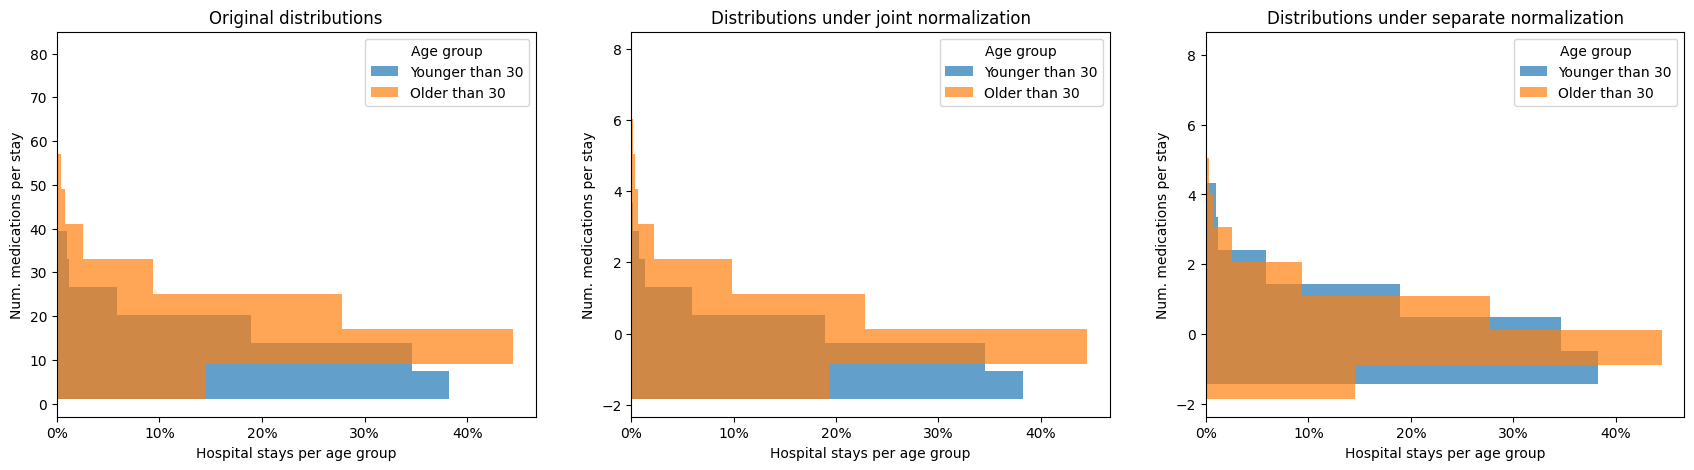

In [33]:
plot_hist_normalization(
    adata,
    adata_scaled_together,
    adata_scaled_separate,
    group_key="Age group",
    var_of_interest="num_medications",
    pretty_name="Num. medications per stay",
)
plt.savefig("normalization_bias.pdf", dpi=300, bbox_inches="tight")